<a href="https://colab.research.google.com/github/Rony-pat/Clases/blob/main/Actividad_21_Aprendizaje_Supervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [ ]:
data = pd.read_csv('train-data.csv')
test = pd.read_csv('test-data.csv')

In [ ]:
# Instalar la librería "lightgbm" que es un potente algoritmo de aprendizaje␣ ↪automático para árboles de decisión.
%pip install lightgbm
# Instalar la librería "xgboost" que es un algoritmo de aprendizaje automático␣ ↪optimizado para árboles de decisión.
%pip install xgboost
# Instalar la librería "catboost" que es otro algoritmo de aprendizaje␣ ↪automático optimizado para árboles de decisión.
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 6.8 MB/s eta 0:00:00


In [ ]:
 # Importar la librería "matplotlib" para crear gráficos y visualizaciones.
import matplotlib
# Importar "matplotlib.pyplot" como "plt" para acceder a sus funciones.
import matplotlib.pyplot as plt
# Importar "matplotlib.style" como "style" para ajustar el estilo de los␣ ↪gráficos.
import matplotlib.style as style
4
 # Importar la librería "numpy" para realizar cálculos numéricos.
import numpy as np
# Importar la librería "pandas" para el manejo y análisis de datos.
import pandas as pd
# Importar "plotly.express" como "px" para crear visualizaciones interactivas.
import plotly.express as px
# Importar la librería "seaborn" para mejorar la visualización de datos.
import seaborn as sns
# Importar "scipy.stats" para realizar análisis estadísticos y pruebas.
from scipy import stats
# Importar la librería "warnings" para manejar advertencias.
import warnings
# Configurar el filtro de advertencias para que las ignore.
warnings.filterwarnings("ignore")

In [ ]:
 # Importar "LGBMClassifier" de la librería "lightgbm" para utilizar un␣ ↪clasificador LightGBM.
# from lightgbm import LGBMClassifier
# Importar módulos de "sklearn" para métricas, validación cruzada y␣ ↪preprocesamiento de datos.
from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing
# Importar "make_classification" de "sklearn.datasets" para crear datos de␣ ↪clasificación sintéticos.
from sklearn.datasets import make_classification
# Importar clases de "sklearn.ensemble" para modelos de conjunto.
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
# Importar modelos de regresión y clasificación de "sklearn.linear_model".
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Ridge


 # Importar funciones y clases específicas para métricas.
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import ConfusionMatrixDisplay
# Importar funciones y clases de "sklearn.model_selection" para validación␣ ↪cruzada y división de datos.
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
# Importar el clasificador "GaussianNB" de "sklearn.naive_bayes" para Naive␣ ↪Bayes.
from sklearn.naive_bayes import GaussianNB
# Importar clasificadores y regresores basados en vecinos más cercanos de␣ ↪"sklearn.neighbors".
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
# Importar clases de "sklearn.preprocessing" para escalado y normalización.
from sklearn.preprocessing import StandardScaler, Normalizer
# Importar modelos de árbol de decisión de "sklearn.tree" para clasificación y␣ ↪regresión.
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
# Importar clases de "sklearn.ensemble" para modelos de conjunto adicionales.
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor
# Importar "MLPRegressor" de "sklearn.neural_network" para redes neuronales.
from sklearn.neural_network import MLPRegressor

In [ ]:
data.isnull().sum()

,0
Unnamed: 0,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,2
Engine,36


In [ ]:
test.isnull().sum()

,0
Unnamed: 0,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,0
Engine,10


In [ ]:
data = data.drop('New_Price', axis=1)
data = data.drop('Unnamed: 0', axis=1)
test = test.drop('New_Price', axis=1)
test = test.drop('Unnamed: 0', axis=1)

In [ ]:
data = data.dropna(how='any')
test = test.dropna(how='any')

In [ ]:
data.shape

(5975, 12)

In [ ]:
test.shape

(1223, 11)

In [ ]:
listtrain = data['Name']
listtest = test['Name']
# prints the missing in listrain
print("Missing values in first list:", (set(listtest).difference(listtrain)))

Missing values in first list: {'Maruti Ciaz VDi Option SHVS', 'Land Rover Freelander 2 S Business Edition', 'Maruti Swift VVT ZXI', 'Honda BRV i-DTEC V MT', 'Mahindra Scorpio SLX 2.6 Turbo 8 Str', 'Toyota Etios Cross 1.2L G', 'Mahindra Bolero Power Plus ZLX', 'Maruti A-Star Zxi', 'Maruti Ritz VDi ABS', 'Maruti Ertiga VXI Petrol', 'Toyota Etios Liva VD', 'Land Rover Range Rover HSE', 'Maruti Ciaz VXi', 'Hyundai Verna 1.4 CX', 'Chevrolet Enjoy TCDi LS 7 Seater', 'Nissan Terrano XE 85 PS', 'Hyundai Accent GLX', 'Mahindra Bolero SLX', 'Mahindra KUV 100 G80 K4 Plus 5Str', 'Mercedes-Benz B Class B180 Sport', 'Fiat Grande Punto 1.2 Emotion', 'Honda City i DTec VX Option BL', 'Hyundai Creta 1.6 VTVT Base', 'BMW 5 Series 530i Sport Line', 'Hyundai Elite i20 Magna Plus', 'Jaguar XF 2.0 Petrol Portfolio', 'Maruti Ignis 1.2 AMT Delta', 'Honda Jazz VX CVT', 'Mahindra TUV 300 2015-2019 T8 AMT', 'Maruti Versa DX2', 'Fiat Punto EVO 1.3 Emotion', 'Nissan Teana XL', 'Toyota Camry MT with Moonroof', 'Lan

In [ ]:
data['Cars'] = data['Name'].str.split(" ").str[0] + ' ' +data['Name'].str.split(" ").str[1]
test['Cars'] = test['Name'].str.split(" ").str[0] + ' ' +test['Name'].str.split(" ").str[1]

In [ ]:
set(test['Cars']).issubset(set(data['Cars']))

False

In [ ]:
listtrain = data['Cars']
listtest = test['Cars']
# prints the missing and additional elements in list1
print("Missing values in first list:", (set(listtest).difference(listtrain)))

Missing values in first list: {'Nissan 370Z', 'Bentley Flying', 'Toyota Land', 'Hindustan Motors', 'OpelCorsa 1.4Gsi', 'Isuzu MU', 'Fiat Abarth'}


In [ ]:
data.head(3)

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Cars
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75,Maruti Wagon
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50,Hyundai Creta
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50,Honda Jazz


In [ ]:
data['Mileage'] = data['Mileage'].str.replace(' kmpl','')
data['Mileage'] = data['Mileage'].str.replace(' km/kg','')
data['Engine'] = data['Engine'].str.replace(' CC','')
data['Power'] = data['Power'].str.replace('null bhp','112')
data['Power'] = data['Power'].str.replace(' bhp','')
test['Mileage'] = test['Mileage'].str.replace(' kmpl','')
test['Mileage'] = test['Mileage'].str.replace(' km/kg','')
test['Engine'] = test['Engine'].str.replace(' CC','')
test['Power'] = test['Power'].str.replace('null bhp','112')
test['Power'] = test['Power'].str.replace(' bhp','')

In [ ]:
data.isnull().sum()

,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,0
Engine,0
Power,0


In [ ]:
test.isnull().sum()

,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,0
Engine,0
Power,0


In [ ]:
data.dtypes

,0
Name,object
Location,object
Year,int64
Kilometers_Driven,int64
Fuel_Type,object
Transmission,object
Owner_Type,object
Mileage,object
Engine,object
Power,object


In [ ]:
data['Mileage'] = data['Mileage'].astype(float)
data['Mileage'] = data['Mileage'].astype(float)
data['Engine'] = data['Engine'].astype(float)
data['Power'] = data['Power'].astype(float)
test['Mileage'] = test['Mileage'].astype(float)
test['Mileage'] = test['Mileage'].astype(float)
test['Engine'] = test['Engine'].astype(float)
test['Power'] = test['Power'].astype(float)

In [ ]:
data.describe()

,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,5975.000000,5.975000e+03,5975.000000,5975.000000,5975.000000,5975.000000,5975.000000
mean,2013.386778,5.867431e+04,18.179408,1621.606695,113.254882,5.278828,9.501647
std,3.247238,9.155851e+04,4.521801,601.036987,53.415632,0.808959,11.205736
min,1998.000000,1.710000e+02,0.000000,624.000000,34.200000,0.000000,0.440000
25%,2012.000000,3.390800e+04,15.200000,1198.000000,77.000000,5.000000,3.500000
50%,2014.000000,5.300000e+04,18.160000,1493.000000,98.600000,5.000000,5.650000
75%,2016.000000,7.300000e+04,21.100000,1984.000000,138.100000,5.000000,9.950000
max,2019.000000,6.500000e+06,33.540000,5998.000000,560.000000,10.000000,160.000000


In [ ]:
feature = ['Cars', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission',
           'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats','Price']
data = pd.DataFrame(data, columns=feature)
feature1 = ['Cars', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission',
            'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats']
test = pd.DataFrame(test, columns=feature1)
data = pd.DataFrame(data, columns=feature)
feature1 = ['Cars', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission',
            'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats']
test = pd.DataFrame(test, columns=feature1)
feature1 = ['Cars', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission',
            'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats']
test = pd.DataFrame(test, columns=feature1)
data = pd.DataFrame(data, columns=feature)
feature1 = ['Cars', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission',
            'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats']
test = pd.DataFrame(test, columns=feature1)
data = pd.DataFrame(data, columns=feature)
feature1 = ['Cars', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission',
            'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats']
test = pd.DataFrame(test, columns=feature1)
feature1 = ['Cars', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission',
            'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats']
test = pd.DataFrame(test, columns=feature1)

In [ ]:
data.head(3)

,Cars,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75
1,Hyundai Creta,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
2,Honda Jazz,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50


Skewness: 3.334741
Kurtosis: 17.073183


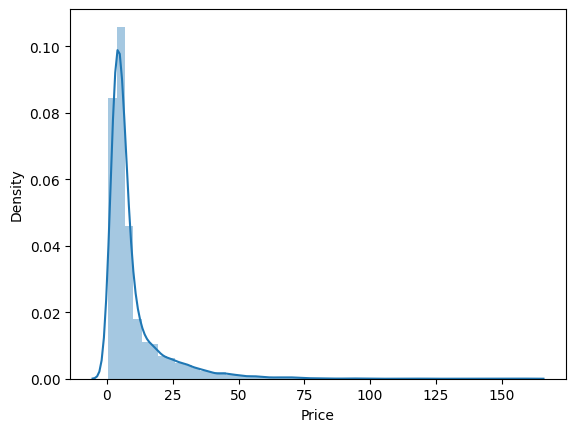

In [ ]:
sns.distplot(data['Price'])
print("Skewness: %f" % data['Price'].skew())
print("Kurtosis: %f" % data['Price'].kurt())

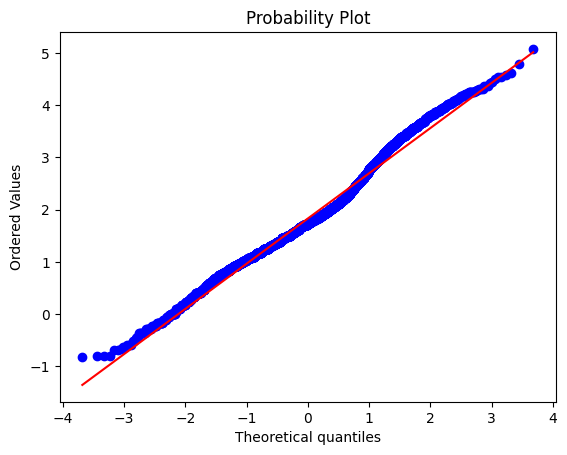

In [ ]:
#applying log transformation
data['Price'] = np.log(data['Price'])
#transformed histogram and normal probability plot #sns.distplot(data['Price']); sns.distplot(data['Price'], fit=None);
fig = plt.figure()
res = stats.probplot(data['Price'], plot=plt)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5975 entries, 0 to 6018
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Cars               5975 non-null   object 
 1   Location           5975 non-null   object 
 2   Year               5975 non-null   int64  
 3   Kilometers_Driven  5975 non-null   int64  
 4   Fuel_Type          5975 non-null   object 
 5   Transmission       5975 non-null   object 
 6   Owner_Type         5975 non-null   object 
 7   Mileage            5975 non-null   float64
 8   Engine             5975 non-null   float64
 9   Power              5975 non-null   float64
 10  Seats              5975 non-null   float64
 11  Price              5975 non-null   float64
dtypes: float64(5), int64(2), object(5)
memory usage: 606.8+ KB


In [ ]:
data_reduced = data.drop(["Cars","Location","Fuel_Type","Transmission","Owner_Type"], axis=1,inplace=False)
data_reduced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5975 entries, 0 to 6018
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               5975 non-null   int64  
 1   Kilometers_Driven  5975 non-null   int64  
 2   Mileage            5975 non-null   float64
 3   Engine             5975 non-null   float64
 4   Power              5975 non-null   float64
 5   Seats              5975 non-null   float64
 6   Price              5975 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 373.4 KB


In [ ]:
# Find most important features relative to target Price
print("Find most important features relative to Price-target")
corr = data_reduced.corr()
corr.sort_values(["Price"], ascending = False, inplace = True)
print(corr.Price)

Find most important features relative to Price-target
Price                1.000000
Power                0.755995
Engine               0.687712
Year                 0.503999
Seats                0.163818
Kilometers_Driven   -0.047187
Mileage             -0.265965
Name: Price, dtype: float64


In [ ]:
px.treemap(data.groupby(by='Fuel_Type').sum().reset_index(), path=['Fuel_Type'], labels='Fuel_Type',
           values='Price', title='Price vs Fuel_type')

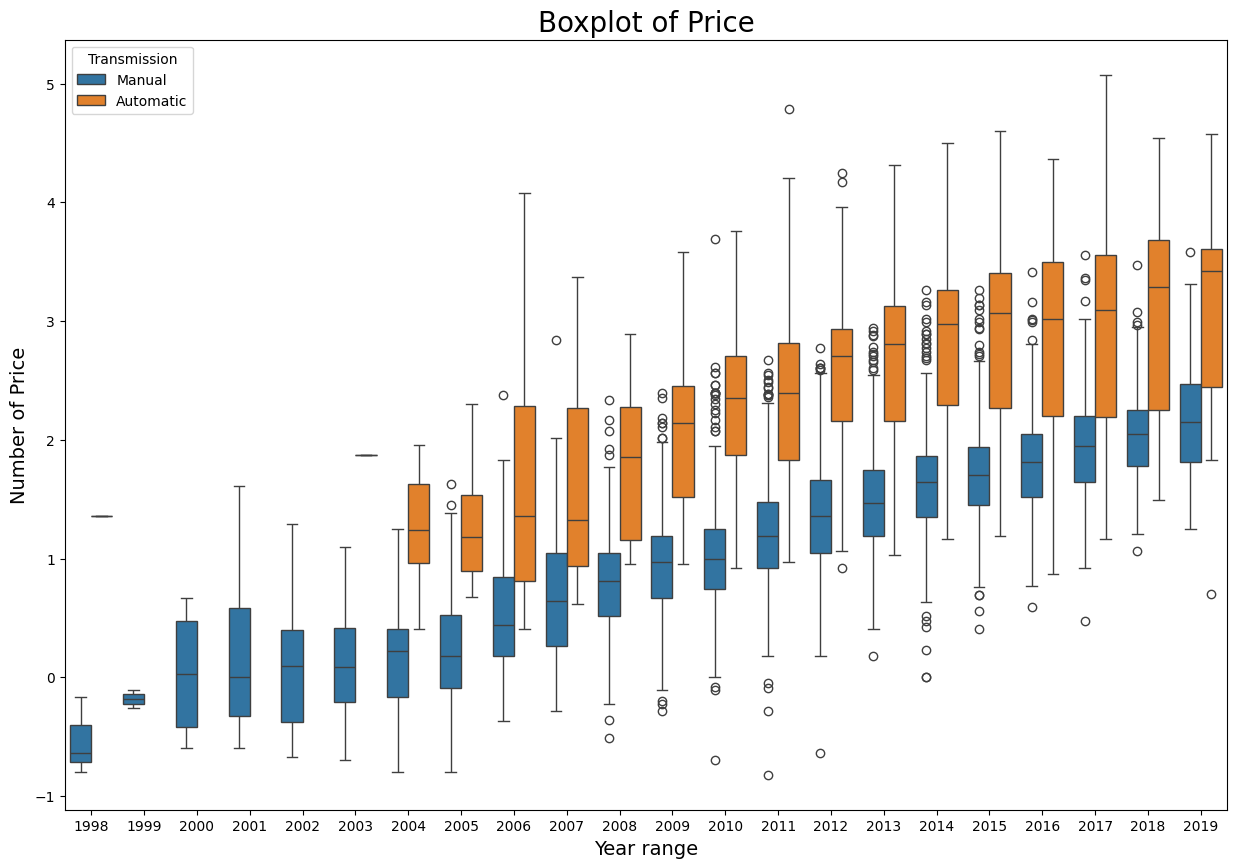

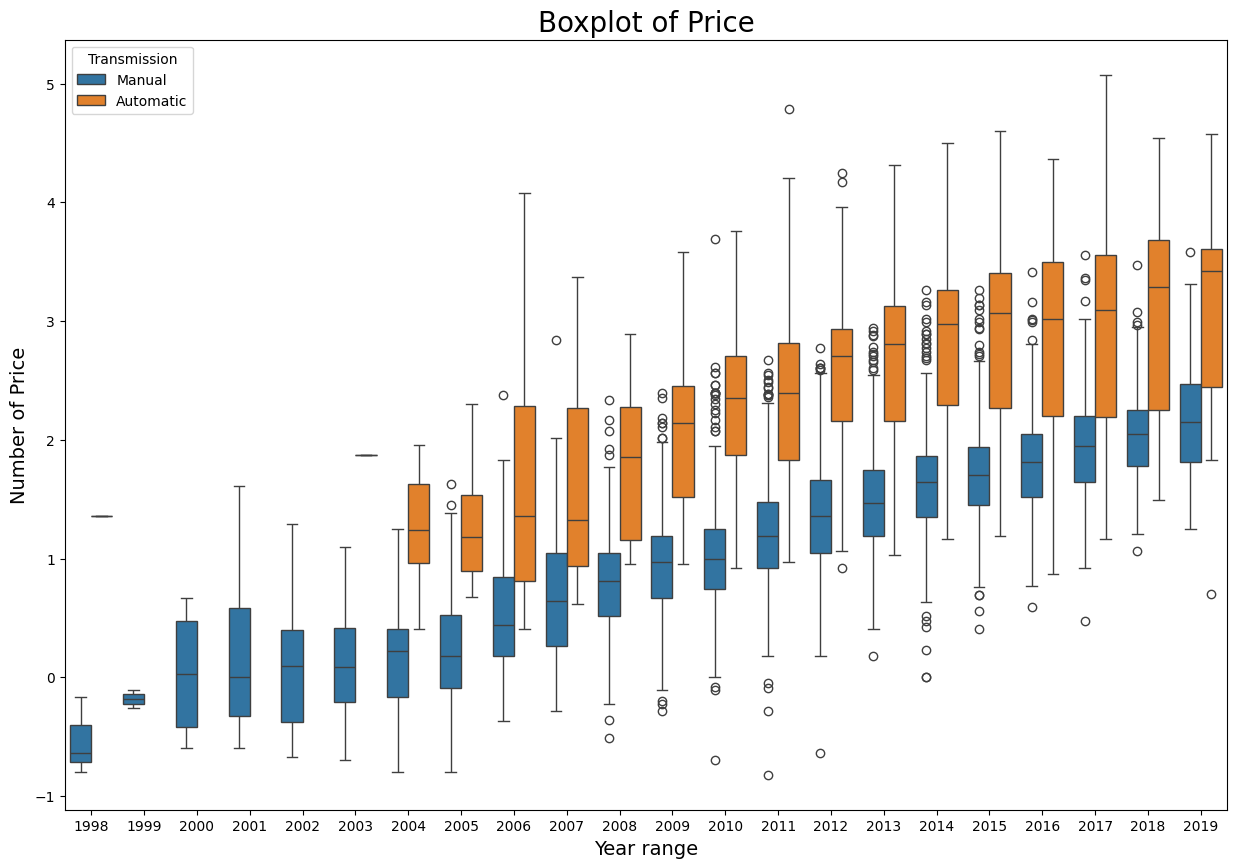

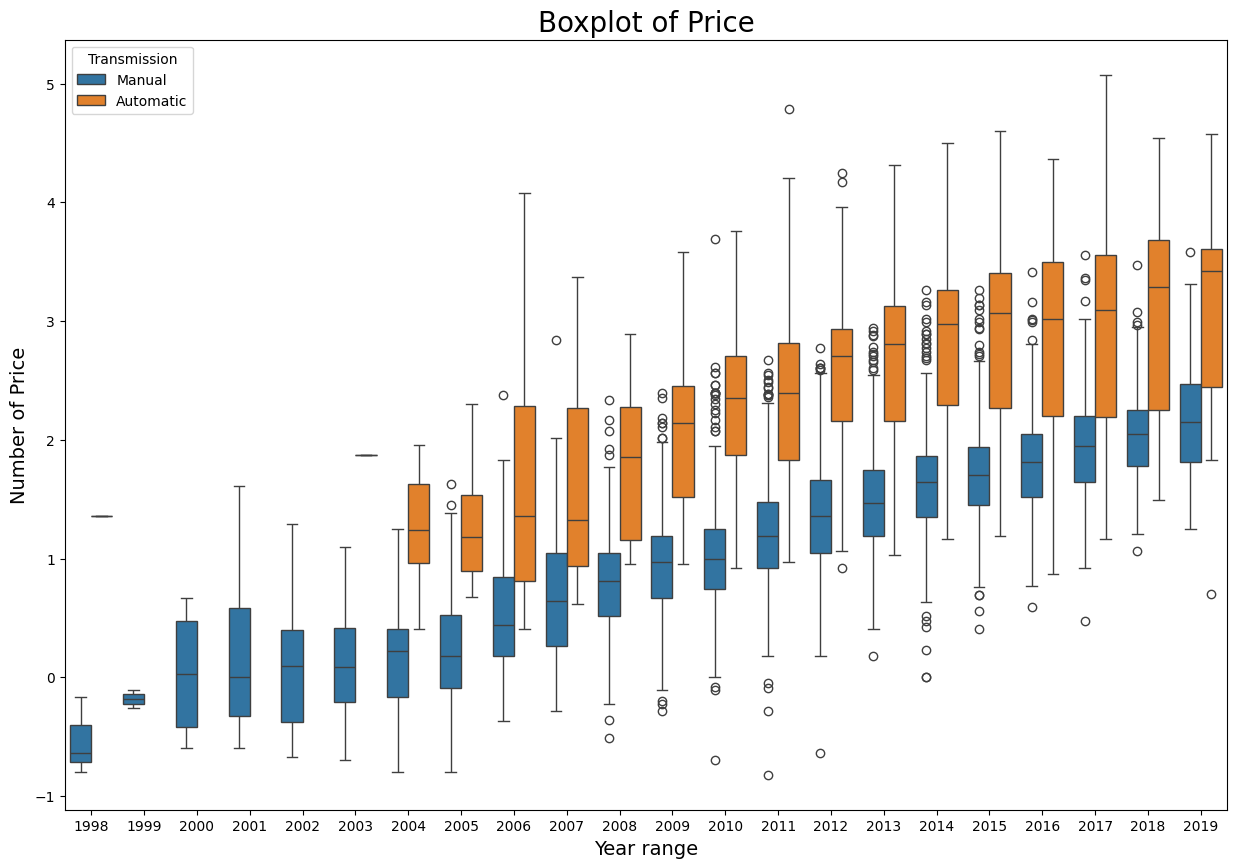

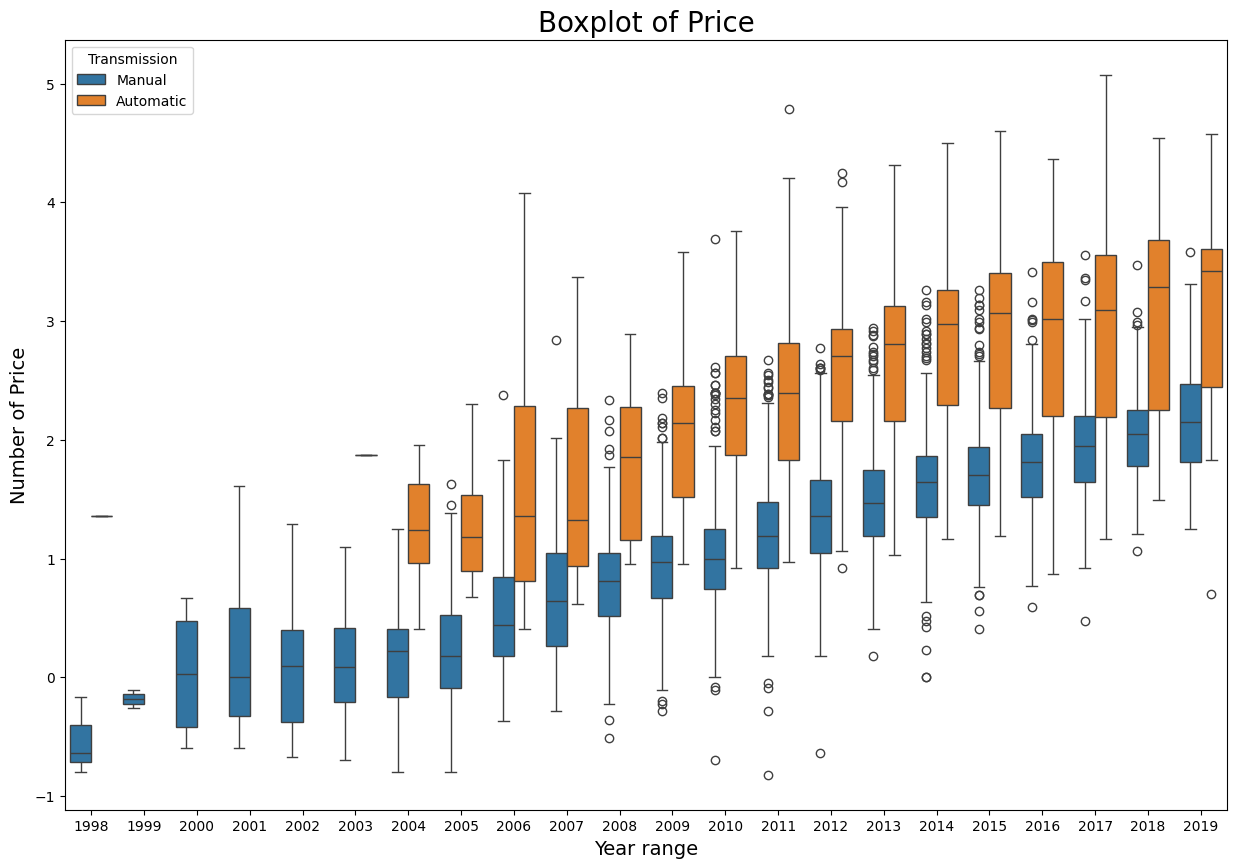

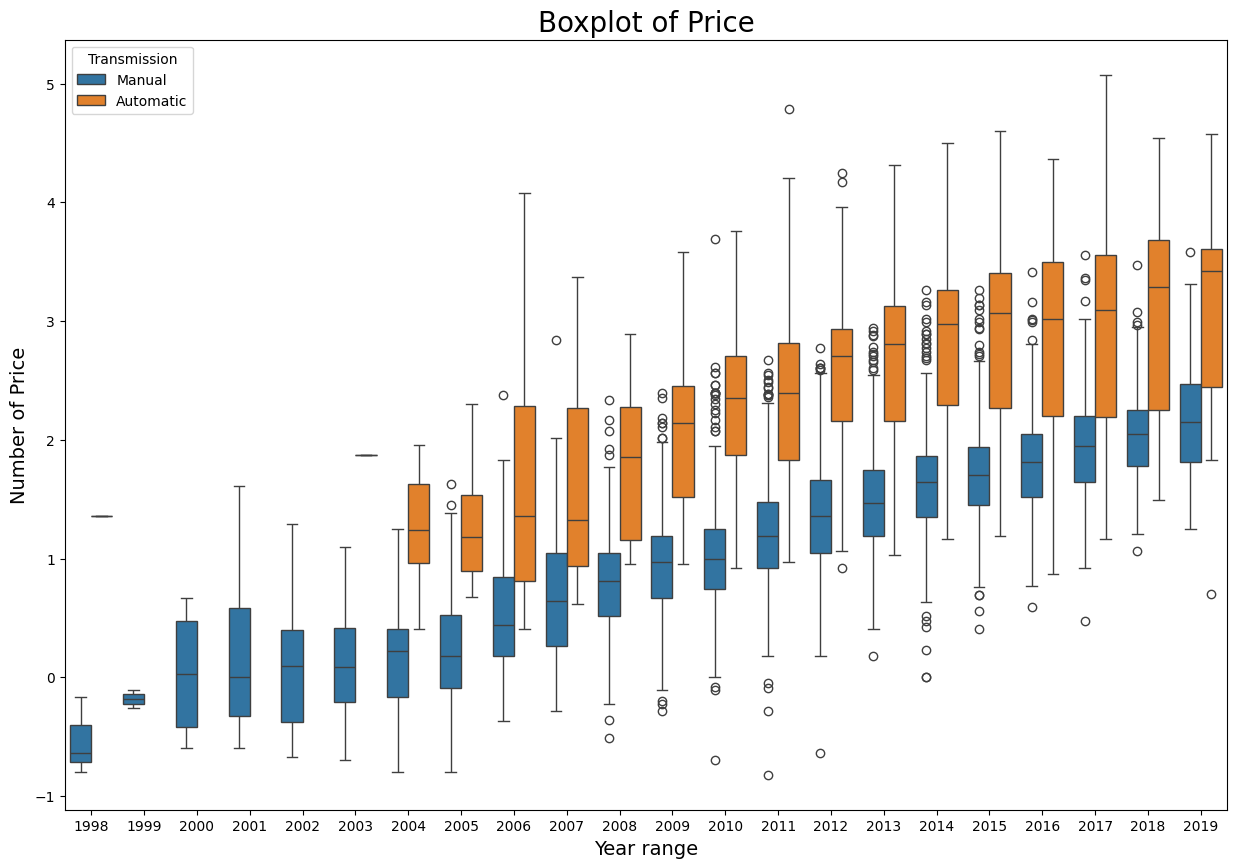

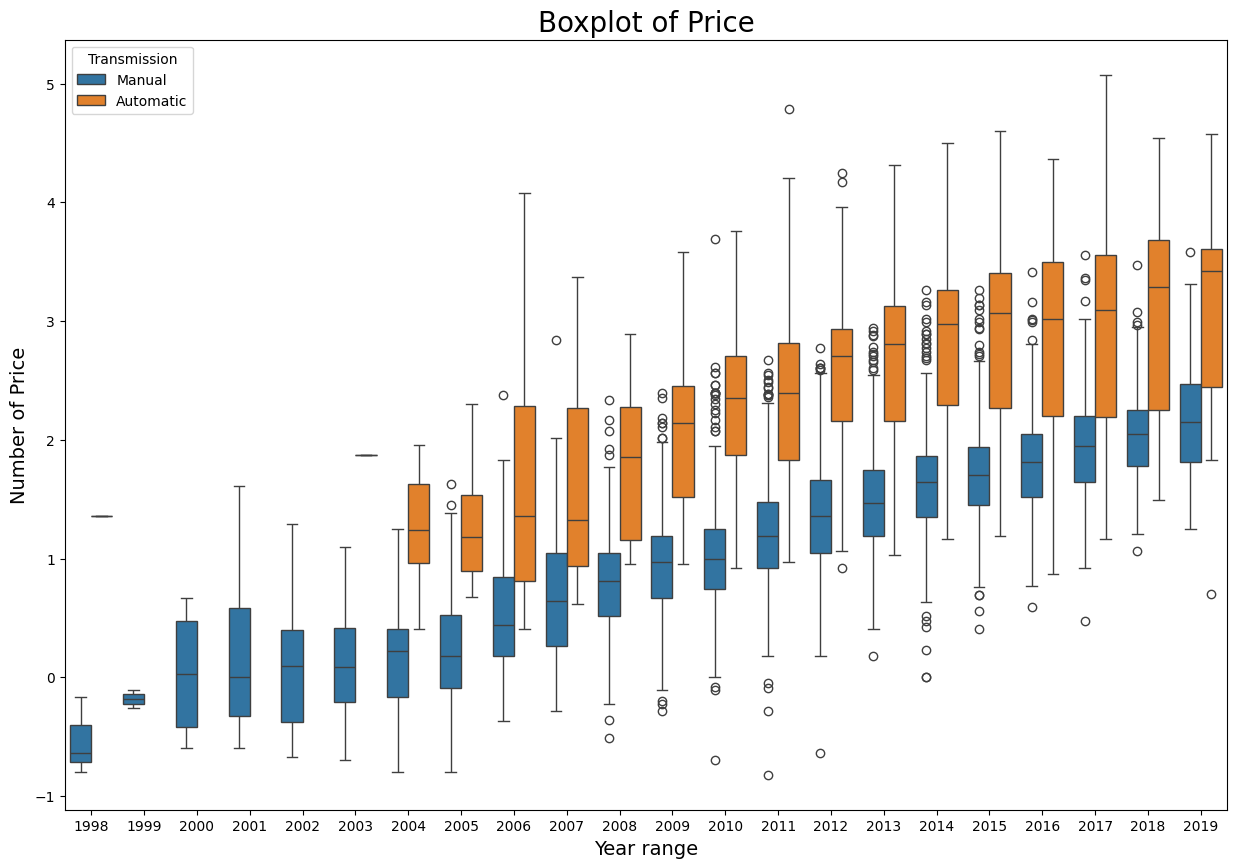

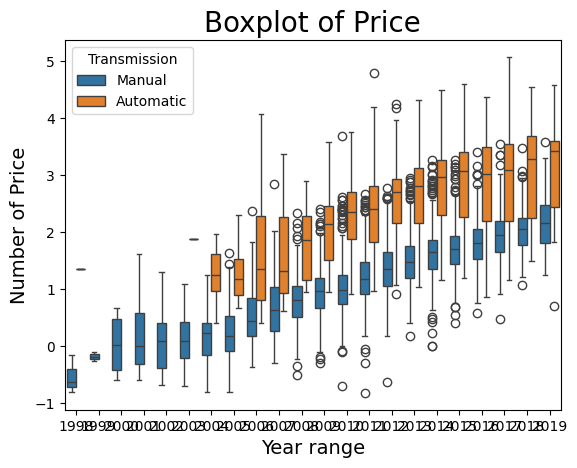

In [ ]:
yprop = 'Price'
yprop = 'Price'
xprop = 'Power'
h= 'Fuel_Type'
px.scatter(data, x=xprop, y=yprop, color=h, marginal_y="violin", marginal_x="box", trendline="ols", template="simple_white")
yprop = 'Price'
xprop = 'Engine'
h= 'Transmission'
px.scatter(data, x=xprop, y=yprop, color=h, marginal_y="violin", marginal_x="box", trendline="ols", template="simple_white")
plt.figure(figsize=(15,10))
xprop = 'Year'
yprop = 'Price'
sns.boxplot(data=data, x=xprop, y=yprop, hue='Transmission')
plt.xlabel('{} range'.format(xprop), size=14)
plt.ylabel('Number of {}'.format(yprop), size=14)
plt.title('Boxplot of {}'.format(yprop), size=20)
plt.show()
yprop = 'Price'
yprop = 'Price'
xprop = 'Power'
h= 'Fuel_Type'
px.scatter(data, x=xprop, y=yprop, color=h, marginal_y="violin", marginal_x="box", trendline="ols", template="simple_white")
yprop = 'Price'
xprop = 'Engine'
h= 'Transmission'
px.scatter(data, x=xprop, y=yprop, color=h, marginal_y="violin", marginal_x="box", trendline="ols", template="simple_white")
plt.figure(figsize=(15,10))
xprop = 'Year'
yprop = 'Price'
sns.boxplot(data=data, x=xprop, y=yprop, hue='Transmission')
plt.xlabel('{} range'.format(xprop), size=14)
plt.ylabel('Number of {}'.format(yprop), size=14)
plt.title('Boxplot of {}'.format(yprop), size=20)
plt.show()
xprop = 'Engine'
h= 'Transmission'
px.scatter(data, x=xprop, y=yprop, color=h, marginal_y="violin", marginal_x="box", trendline="ols", template="simple_white")
plt.figure(figsize=(15,10))
xprop = 'Year'
yprop = 'Price'
sns.boxplot(data=data, x=xprop, y=yprop, hue='Transmission')
plt.xlabel('{} range'.format(xprop), size=14)
plt.ylabel('Number of {}'.format(yprop), size=14)
plt.title('Boxplot of {}'.format(yprop), size=20)
plt.show()
yprop = 'Price'
yprop = 'Price'
xprop = 'Power'
h= 'Fuel_Type'
px.scatter(data, x=xprop, y=yprop, color=h, marginal_y="violin", marginal_x="box", trendline="ols", template="simple_white")
yprop = 'Price'
xprop = 'Engine'
h= 'Transmission'
px.scatter(data, x=xprop, y=yprop, color=h, marginal_y="violin", marginal_x="box", trendline="ols", template="simple_white")
plt.figure(figsize=(15,10))
xprop = 'Year'
yprop = 'Price'
sns.boxplot(data=data, x=xprop, y=yprop, hue='Transmission')
plt.xlabel('{} range'.format(xprop), size=14)
plt.ylabel('Number of {}'.format(yprop), size=14)
plt.title('Boxplot of {}'.format(yprop), size=20)
plt.show()
yprop = 'Price'
yprop = 'Price'
xprop = 'Power'
h= 'Fuel_Type'
px.scatter(data, x=xprop, y=yprop, color=h, marginal_y="violin", marginal_x="box", trendline="ols", template="simple_white")
yprop = 'Price'
xprop = 'Engine'
h= 'Transmission'
px.scatter(data, x=xprop, y=yprop, color=h, marginal_y="violin", marginal_x="box", trendline="ols", template="simple_white")
plt.figure(figsize=(15,10))
xprop = 'Year'
yprop = 'Price'
sns.boxplot(data=data, x=xprop, y=yprop, hue='Transmission')
plt.xlabel('{} range'.format(xprop), size=14)
plt.ylabel('Number of {}'.format(yprop), size=14)
plt.title('Boxplot of {}'.format(yprop), size=20)
plt.show()
xprop = 'Engine'
h= 'Transmission'
px.scatter(data, x=xprop, y=yprop, color=h, marginal_y="violin", marginal_x="box", trendline="ols", template="simple_white")
plt.figure(figsize=(15,10))
xprop = 'Year'
yprop = 'Price'
sns.boxplot(data=data, x=xprop, y=yprop, hue='Transmission')
plt.xlabel('{} range'.format(xprop), size=14)
plt.ylabel('Number of {}'.format(yprop), size=14)
plt.title('Boxplot of {}'.format(yprop), size=20)
plt.show()
xprop = 'Year'
yprop = 'Price'
sns.boxplot(data=data, x=xprop, y=yprop, hue='Transmission')
plt.xlabel('{} range'.format(xprop), size=14)
plt.ylabel('Number of {}'.format(yprop), size=14)
plt.title('Boxplot of {}'.format(yprop), size=20)
plt.show()

In [ ]:
yprop = 'Price'
yprop = 'Price'
xprop = 'Year'
h= 'Owner_Type'
px.scatter(data, x=xprop, y=yprop, color=h, marginal_y="violin", marginal_x="box", trendline="ols", template="simple_white") #fig.update_layout(xaxis_range=[0,5e5])

<Figure size 1500x1000 with 0 Axes>

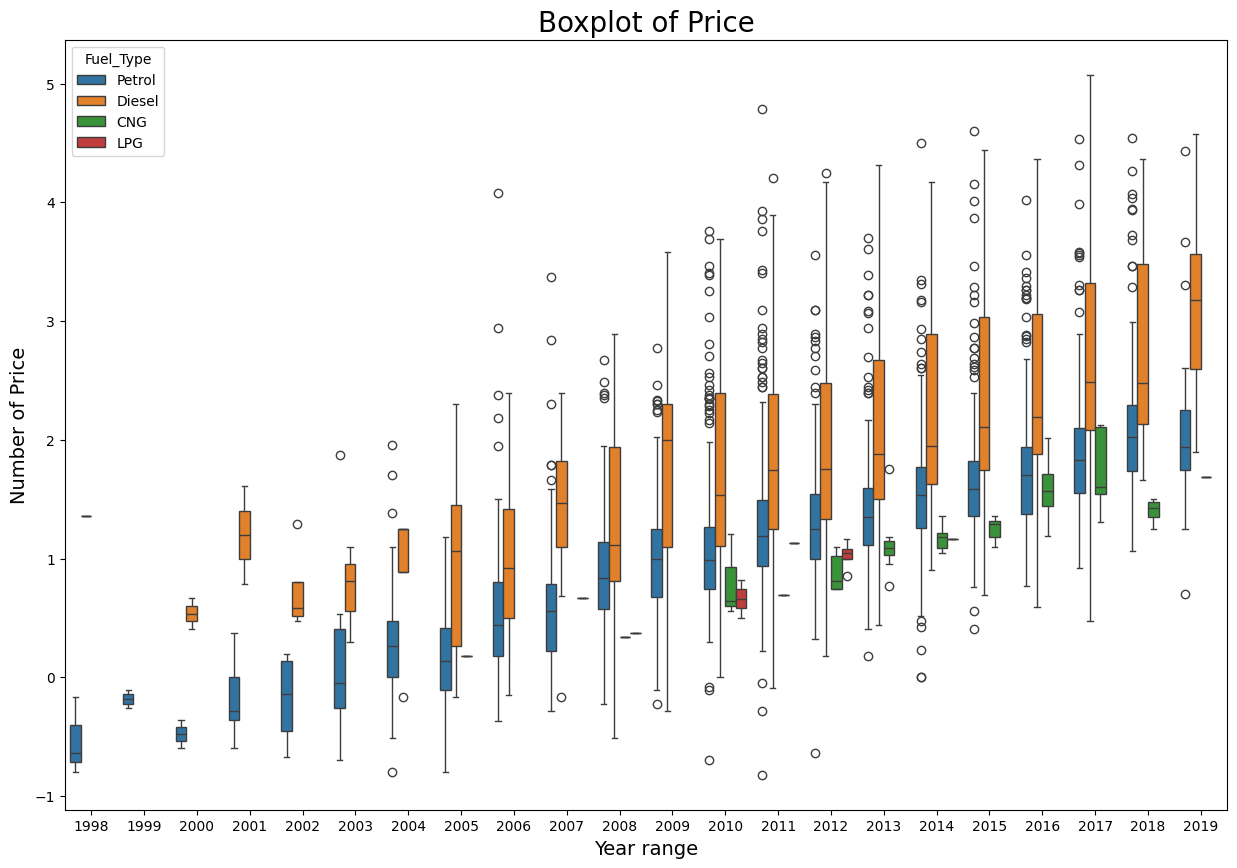

In [ ]:
plt.figure(figsize=(15,10))
plt.figure(figsize=(15,10))
xprop = 'Year'
yprop = 'Price'
sns.boxplot(data=data, x=xprop, y=yprop, hue='Fuel_Type')
plt.xlabel('{} range'.format(xprop), size=14)
plt.ylabel('Number of {}'.format(yprop), size=14)
plt.title('Boxplot of {}'.format(yprop), size=20)
plt.show()

In [ ]:
fig = px.box(data, x='Fuel_Type',y='Price', color='Transmission', notched=True)
fig.update_layout(legend=dict(orientation="h",yanchor="bottom",y=1.02,xanchor="right",x=1))
fig.show()

In [ ]:
px.violin(data, y='Price', x='Seats', color=None, box=True, points="all", hover_data=data.columns)
import plotly.graph_objects as go
fig = go.Figure(data=[go.Pie(labels=data['Fuel_Type'], values=data['Price'], hole=.3)])
px.violin(data, y='Price', x='Seats', color=None, box=True, points="all", hover_data=data.columns)
import plotly.graph_objects as go
fig = go.Figure(data=[go.Pie(labels=data['Fuel_Type'], values=data['Price'], hole=.3)])
fig.update_layout(legend=dict(orientation="h", yanchor="bottom",y=1.02,xanchor="right",x=1))
fig.show()

In [63]:
import copy
df_train=copy.deepcopy(data)
df_test=copy.deepcopy(test)
cols=np.array(data.columns[data.dtypes != object])
for i in df_train.columns:
    if i not in cols:
        df_train[i]=df_train[i].map(str)
        df_test[i]=df_test[i].map(str)
# Remove the second df_train.drop(columns=cols,inplace=True) as it's redundant and causes the error.
df_train.drop(columns=cols,inplace=True) # This line drops the numerical columns from df_train

# Check if 'Price' is in df_test columns before dropping
if 'Price' in df_test.columns:
    df_test.drop(columns=['Price'],inplace=True)  # Drop 'Price' only if it exists in df_test
# The following lines are removed as they try to drop the same columns again, leading to KeyError
# df_train.drop(columns=cols,inplace=True)
# df_test.drop(columns=np.delete(cols,len(cols)-1),inplace=True)

In [71]:
import copy
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict

df_train = copy.deepcopy(data)
df_test = copy.deepcopy(test)
cols = np.array(data.columns[data.dtypes != object])

# Convert categorical columns to string type in both dataframes
for i in df_train.columns:
    if i not in cols:
        df_train[i] = df_train[i].map(str)
        df_test[i] = df_test[i].map(str)

# Drop numerical columns from df_train
df_train.drop(columns=cols, inplace=True)

# Drop 'Price' from df_test if it exists

In [80]:
import copy
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict

df_train = copy.deepcopy(data)
df_test = copy.deepcopy(test)
cols = np.array(data.columns[data.dtypes != object])

# Convert categorical columns to string type in both dataframes
for i in df_train.columns:
    if i not in cols:
        df_train[i] = df_train[i].map(str)
        df_test[i] = df_test[i].map(str)

# Drop numerical columns from df_train
df_train.drop(columns=cols, inplace=True)

# Drop 'Price' from df_test if it exists
# ... (rest of your code)

from sklearn.preprocessing import LabelEncoder
from collections import defaultdict
import numpy as np
import pandas as pd  # Import pandas for pd.concat

# build dictionary function
cols = np.array(data.columns[data.dtypes != object])
d = defaultdict(LabelEncoder)

# Fit the LabelEncoders on the combined unique values from both train and test data
for col in df_train.columns:
    # Combine unique values from both dataframes for fitting
    # Convert all values to strings before fitting
    all_values = pd.concat([df_train[col], df_test[col]], axis=0).astype(str).unique()
    d[col].fit(all_values)

# only for categorical columns apply dictionary by calling fit_transform
df_train = df_train.apply(lambda x: d[x.name].transform(x))
# Handle unseen values in df_test during transform
df_test = df_test.apply(lambda x: d[x.name].transform(x.astype(str)) if x.name in d else x) #This line is edited
# Restore numerical columns
df_train[cols] = data[cols]
df_test[np.delete(cols, len(cols) - 1)] = test[np.delete(cols, len(cols) - 1)]

In [81]:
df_test.head(2)

,Cars,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
0,110,4,2014,40929,0,1,0,32.26,998.0,58.2,4.0
1,110,3,2013,54493,3,1,2,24.70,796.0,47.3,5.0


In [82]:
df_train.head(2)

,Cars,Location,Fuel_Type,Transmission,Owner_Type,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
0,128,9,0,1,0,2010,72000,26.60,998.0,58.16,5.0,0.559616
1,68,10,1,1,0,2015,41000,19.67,1582.0,126.20,5.0,2.525729


In [85]:
ftrain = ['Cars', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission',
          'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats','Price']
def Definedata():
    # define dataset
    data2 = df_train[ftrain]
    X = data2.drop(columns=['Price']).values
    y0 = data2['Price'].values
    lab_enc = preprocessing.LabelEncoder()
    y = lab_enc.fit_transform(y0)
    return X, y
# define dataset
data2 = df_train[ftrain]
X = data2.drop(columns=['Price']).values
y0 = data2['Price'].values
ftrain = ['Cars', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission',
          'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats','Price']
def Definedata():
    # define dataset
    data2 = df_train[ftrain]
    X = data2.drop(columns=['Price']).values
    y0 = data2['Price'].values
    lab_enc = preprocessing.LabelEncoder()
    y = lab_enc.fit_transform(y0)
    return X, y
# define dataset
# data2 = df_train[ftrain]
# X = data2.drop(columns=['Price']).values
# y0 = data2['Price'].values
# lab_enc = preprocessing.LabelEncoder()
# y = lab_enc.fit_transform(y0)
# return X, y

In [90]:
def Models(models):
    model = models
    X, y = Definedata()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 25)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    y_total = model.predict(X)
    print("\t\tError Table")
    print('Mean Absolute Error : ', metrics.mean_absolute_error(y_test, y_pred))
    print('Mean Squared Error : ', metrics.mean_squared_error(y_test, y_pred))
    print('Root Mean Squared Error : ', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
    print('Accuracy on Traing set : ', model.score(X_train,y_train))
    print('Accuracy on Testing set : ', model.score(X_test,y_test))
    return y_total, y

def Featureimportances(models):
    model = models
    model.fit(X_train,y_train)
    importances = model.feature_importances_
    features = df_test.columns[:9]
    imp = pd.DataFrame({'Features': features, 'Importance': importances}) # Corrected to use features
    imp['Sum Importance'] = imp['Importance'].cumsum()
    imp = imp.sort_values(by = 'Importance')
    return imp

def Graph_prediction(n, y_actual, y_predicted):
    y = y_actual
    y_total = y_predicted
    number = n
    aa=[x for x in range(number)]
    plt.figure(figsize=(25,10))
    plt.plot(aa, y[:number], marker='.', label="actual")
    plt.plot(aa, y_total[:number], 'b', label="prediction")
    plt.xlabel('Price prediction of first {} used cars'.format(number), size=15)
    plt.legend(fontsize=15)
    plt.show()

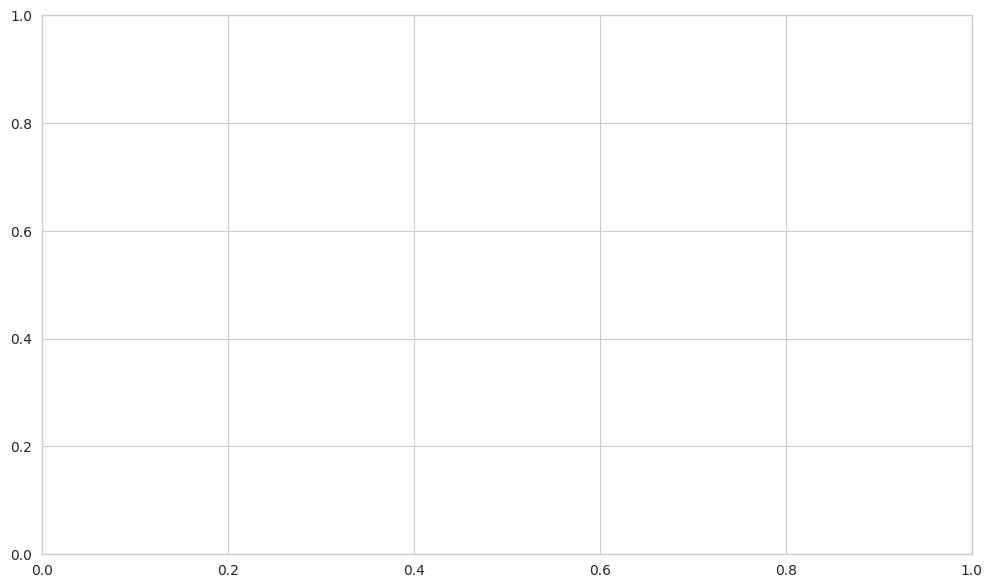

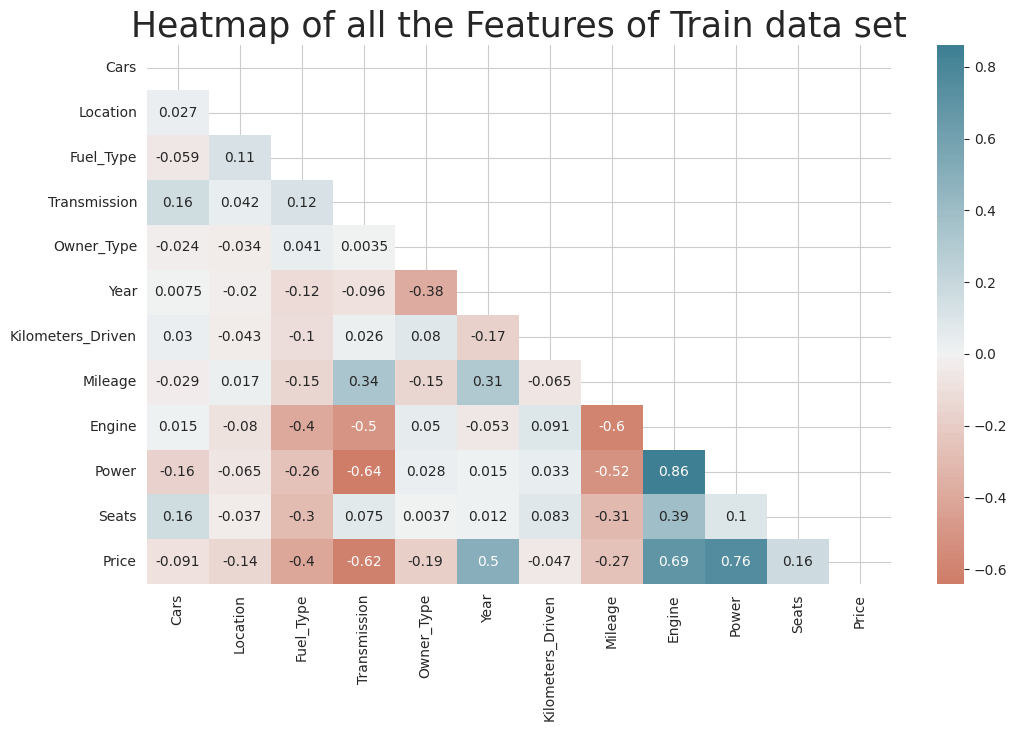

In [93]:
style.use('ggplot')
sns.set_style('whitegrid')
style.use('ggplot')
sns.set_style('whitegrid')
plt.subplots(figsize = (12,7))
## Plotting heatmap. # Generate a mask for the upper triangle (taken from seaborn example gallery)
mask = np.zeros_like(df_train.corr(), dtype=bool)
mask[np.triu_indices_from(mask)] = True
style.use('ggplot')
sns.set_style('whitegrid')
style.use('ggplot')
sns.set_style('whitegrid')
plt.subplots(figsize = (12,7))
## Plotting heatmap. # Generate a mask for the upper triangle (taken from seaborn example gallery)
mask = np.zeros_like(df_train.corr(), dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(df_train.corr(), cmap=sns.diverging_palette(20, 220, n=200), annot=True, mask=mask, center = 0, );
plt.title("Heatmap of all the Features of Train data set", fontsize = 25);
# removed extra "↪"
plt.title("Heatmap of all the Features of Train data set", fontsize = 25);

In [94]:
Acc = pd.DataFrame(index=None, columns=['model','Root Mean Squared ␣ ↪Error','Accuracy on Traing set','Accuracy on Testing set'])

In [97]:
X, y = Definedata()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=25)
regressors = [
    ['DecisionTreeRegressor', DecisionTreeRegressor()],
    ['RandomForestRegressor', RandomForestRegressor()],
    ['MLPRegressor', MLPRegressor()],
    ['AdaBoostRegressor', AdaBoostRegressor()],
    ['ExtraTreesRegressor', ExtraTreesRegressor()]
]
results = []
for mod in regressors:
    name = mod[0]
    model = mod[1]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    ATrS = model.score(X_train, y_train)
    ATeS = model.score(X_test, y_test)
    results.append({
        'model': name,
        'Root Mean Squared Error': RMSE,
        'Accuracy on Training set': ATrS,
        'Accuracy on Testing set': ATeS
    })
Acc = pd.concat([Acc, pd.DataFrame(results)], ignore_index=True)
print(Acc)
# The following lines were causing the error due to unexpected indentation.
# They have been removed as they seem to be a repetition of the 'regressors' list definition.
# If you intended to add more models, you should include them within the original 'regressors' list.
# ['DecisionTreeRegressor', DecisionTreeRegressor()],
# ['RandomForestRegressor', RandomForestRegressor()],
# ['MLPRegressor', MLPRegressor()],
# ['AdaBoostRegressor', AdaBoostRegressor()],
# ['ExtraTreesRegressor', ExtraTreesRegressor()]

#The following line had an indentation error
#results = []
# Removed the indentation
#for mod in regressors: name = mod[0]
#Fixed indentation
#   model = mod[1]
#   model.fit(X_train, y_train)
#   y_pred = model.predict(X_test)
#   RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
#   ATrS = model.score(X_train, y_train)
#   ATeS = model.score(X_test, y_test)
#   results.append({
#      'model': name,
#        'Root Mean Squared Error': RMSE,
#       'Accuracy on Training set': ATrS,
#       'Accuracy on Testing set': ATeS
#})
#Acc = pd.concat([Acc, pd.DataFrame(results)], ignore_index=True) print(Acc)
#Fixed indentation and put print in next line
#Acc = pd.concat([Acc, pd.DataFrame(results)], ignore_index=True)
#print(Acc)

                   model Root Mean Squared ␣ ↪Error Accuracy on Traing set  \
0  DecisionTreeRegressor                        NaN                    NaN   
1  RandomForestRegressor                        NaN                    NaN   
2           MLPRegressor                        NaN                    NaN   
3      AdaBoostRegressor                        NaN                    NaN   
4    ExtraTreesRegressor                        NaN                    NaN   

   Accuracy on Testing set  Root Mean Squared Error  Accuracy on Training set  
0                 0.889289               115.300708                  0.999993  
1                 0.941310                83.949533                  0.991498  
2                 0.695367               191.259880                  0.725593  
3                 0.813222               149.761102                  0.827069  
4                 0.946748                79.965652                  0.999993  


In [98]:
Acc.sort_values(by='Accuracy on Testing set')

,model,Root Mean Squared ␣ ↪Error,Accuracy on Traing set,Accuracy on Testing set,Root Mean Squared Error,Accuracy on Training set
2,MLPRegressor,NaN,NaN,0.695367,191.259880,0.725593
3,AdaBoostRegressor,NaN,NaN,0.813222,149.761102,0.827069
0,DecisionTreeRegressor,NaN,NaN,0.889289,115.300708,0.999993
1,RandomForestRegressor,NaN,NaN,0.941310,83.949533,0.991498
4,ExtraTreesRegressor,NaN,NaN,0.946748,79.965652,0.999993


		Error Table
Mean Absolute Error :  56.03085986216665
Mean Squared Error :  6239.224326854844
Root Mean Squared Error :  78.9887607628759
Accuracy on Traing set :  0.9926353055514496
Accuracy on Testing set :  0.9480411771791412


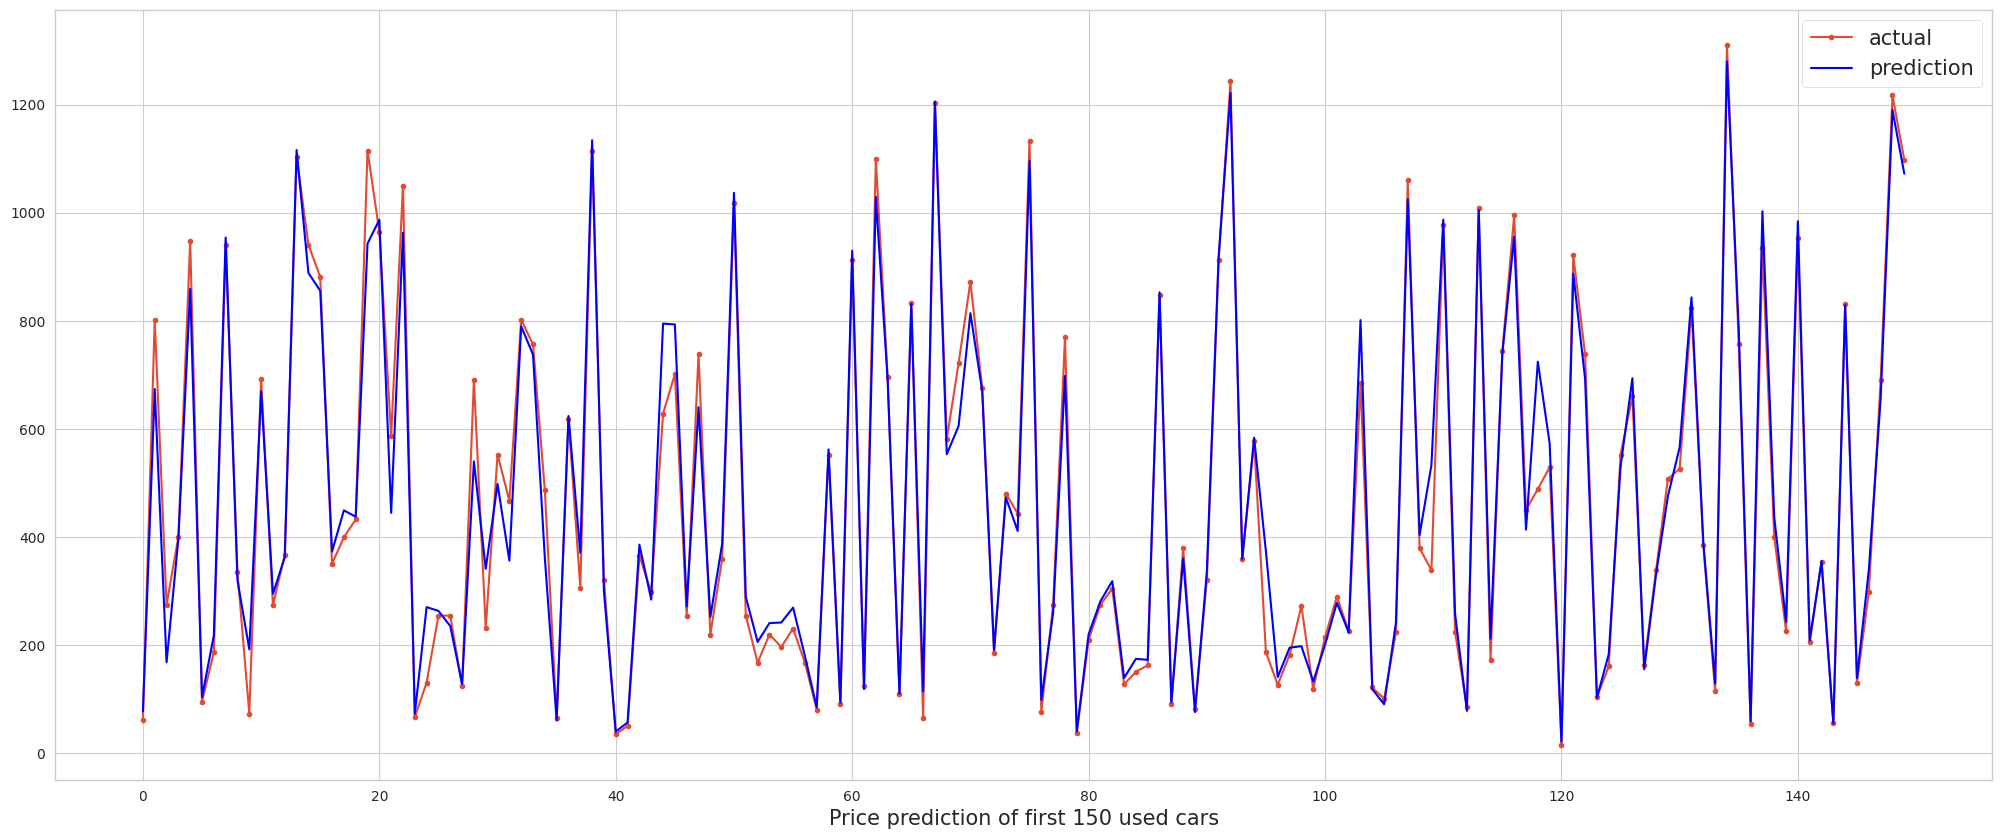

In [102]:
y_predicted, y_actual = Models(RandomForestRegressor(n_estimators=10000,min_samples_split=2,min_samples_leaf=1,max_features='sqrt'))
Graph_prediction(150, y_actual, y_predicted)

		Error Table
Mean Absolute Error :  47.0567497991548
Mean Squared Error :  4775.01882003059
Root Mean Squared Error :  69.10151098225414
Accuracy on Traing set :  0.9947381034525249
Accuracy on Testing set :  0.9602347433208409


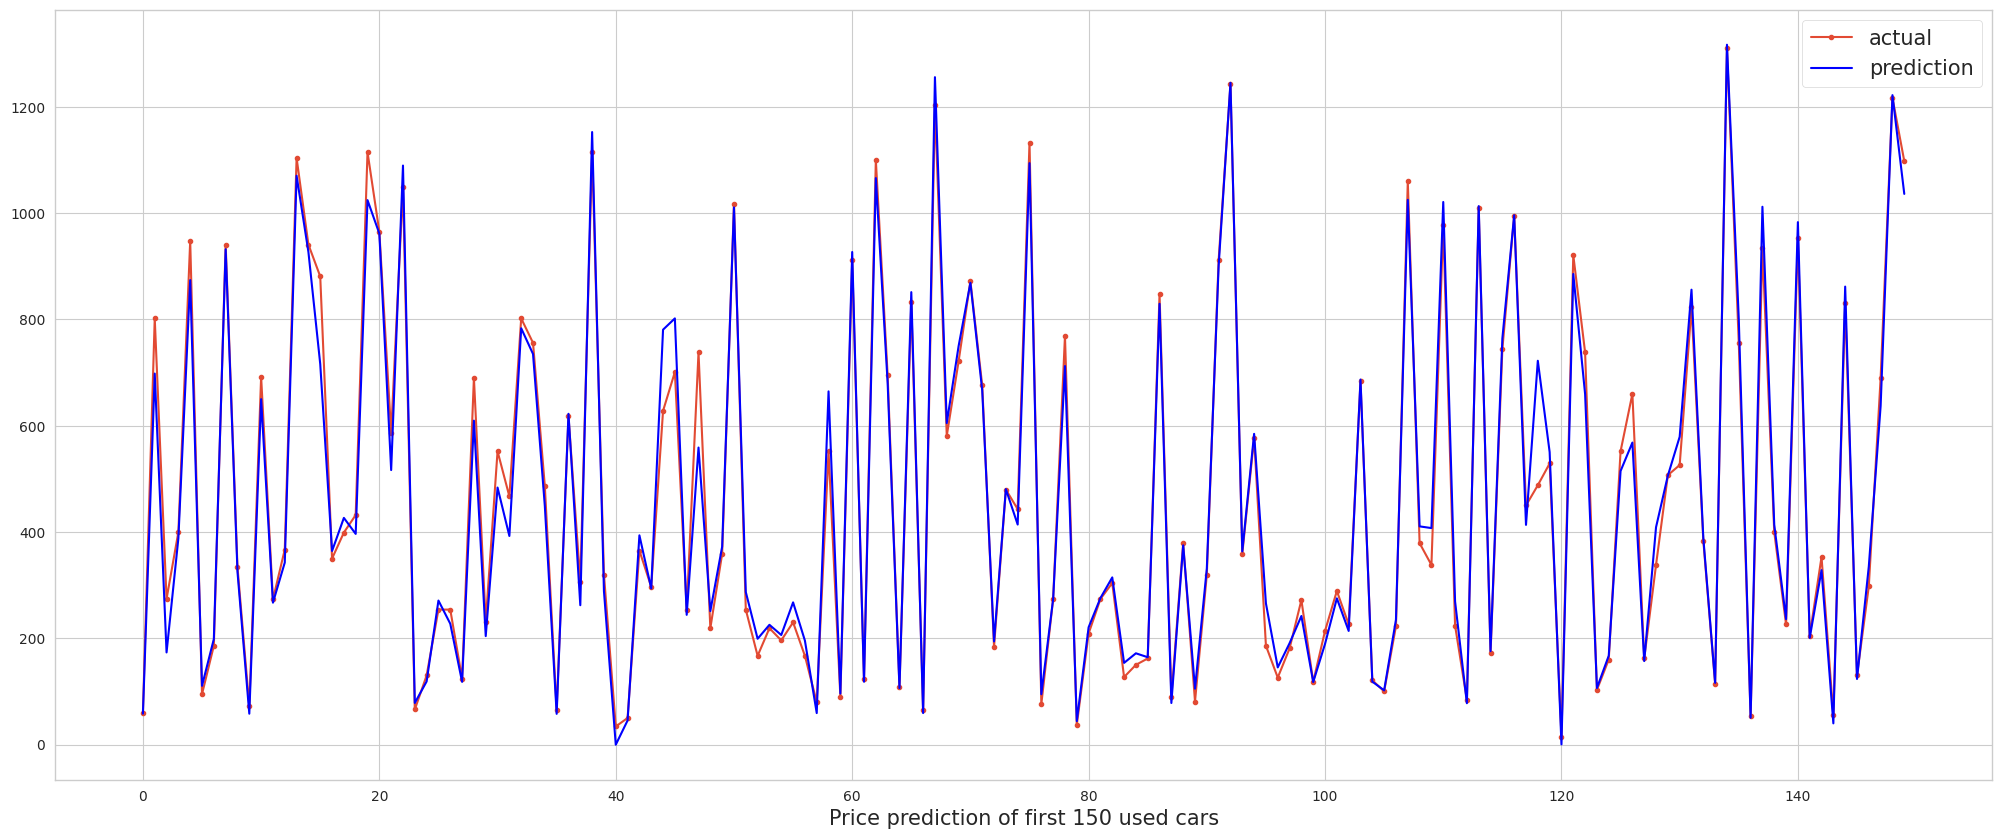

In [106]:
y_predicted, y_actual = Models(GradientBoostingRegressor(random_state=21, n_estimators=3000))
Graph_prediction(150, y_actual, y_predicted)

In [109]:
compare = pd.DataFrame({'Prediction': y_predicted, 'Test Data' : y_actual, 'Abs error': abs(y_actual - y_predicted), 'AAD%': abs(y_actual - y_predicted)/y_actual*100})
compare.head(10)

,Prediction,Test Data,Abs error,AAD%
0,58.088497,60,1.911503,3.185839
1,698.224271,802,103.775729,12.939617
2,173.363825,274,100.636175,36.728531
3,388.248249,400,11.751751,2.937938
4,874.105128,948,73.894872,7.794818
5,110.571423,95,15.571423,16.390971
6,198.584577,186,12.584577,6.765902
7,932.145471,941,8.854529,0.940970
8,324.964986,334,9.035014,2.705094
9,58.051893,72,13.948107,19.372370


In [113]:
model = GradientBoostingRegressor(random_state=21, n_estimators=5000)
feature1 = ['Cars', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type','Transmission',
                        'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats']
X0 = df_test[feature1]
X, y = Definedata()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 25)
model.fit(X_train,y_train)
y_predicted = model.predict(X0)
submission = pd.DataFrame({'Car_id':test.index,'Price':y_predicted})
submission.head(10)
model = GradientBoostingRegressor(random_state=21, n_estimators=5000)
feature1 = ['Cars', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type','Transmission',
                        'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats']
X0 = df_test[feature1]
X, y = Definedata()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 25)
model.fit(X_train,y_train)
y_predicted = model.predict(X0)
submission = pd.DataFrame({'Car_id':test.index,'Price':y_predicted})
submission.head(10)
X0 = df_test[feature1]
X, y = Definedata()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 25)
model.fit(X_train,y_train)
y_predicted = model.predict(X0)
submission = pd.DataFrame({'Car_id':test.index,'Price':y_predicted})
submission.head(10)
submission.head(10)

,Car_id,Price
0,0,229.220688
1,1,157.300412
2,2,933.110908
3,3,237.274792
4,4,273.766839
5,5,758.443125
6,6,1032.597871
7,7,122.656552
8,8,166.785100
9,9,751.605876


In [117]:
#Convert DataFrame to a csv file that can be uploaded
#This is saved in the same directory as your notebook
filename = 'submission.csv' # Assigning the string 'submission.csv' to the variable filename
submission.to_csv(filename,index=True)
print('Saved file: ' + filename)

Saved file: submission.csv
